<a href="https://colab.research.google.com/github/krlakhan2701/ADEQUATE---Qureca_-Course/blob/main/Deutsch_Jozsa_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://gitlab.com/qworld/qeducation/educational-materials/adequate-qbook1/raw/main/qworld/images/adq_1.png" align="left" width=450></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $


_prepared by Berat Yenilen, Utku Birkan, Arda Çınar, Cenk Tüysüz and Özlem Salehi_

<font size="28px" style="font-size:28px;" align="left"><b>Exercise: Deutsch-Jozsa Algorithm </b></font>
<br>
<br><br>

##### <font color="#08b806">Please execute the following cell, it is necessary to distinguish between your local environment and Google Colab's

In [ ]:
import IPython

def in_colab():
    try:
        import google.colab
        return True
    except:
        return False

path_files = "./" if in_colab() else "../qworld/include/"

SolutionToTask3 = lambda: IPython.display.display(IPython.display.Javascript('window.open("{url}");'.format(url='https://colab.research.google.com/drive/1R4H5rzin4L0a_QGWoJIpK1GxVyiwMQpa#scrollTo=I4kDR5nNfhLm' if in_colab() else 'Deutsch_Jozsa_Algorithm_Solutions.ipynb#task3')))
SolutionToTask4 = lambda: IPython.display.display(IPython.display.Javascript('window.open("{url}");'.format(url='https://colab.research.google.com/drive/1R4H5rzin4L0a_QGWoJIpK1GxVyiwMQpa#scrollTo=5K__MmD9fhLm' if in_colab() else 'Deutsch_Jozsa_Algorithm_Solutions.ipynb#task4')))
SolutionToTask5 = lambda: IPython.display.display(IPython.display.Javascript('window.open("{url}");'.format(url='https://colab.research.google.com/drive/1R4H5rzin4L0a_QGWoJIpK1GxVyiwMQpa#scrollTo=1_I1XmUNfhLn' if in_colab() else 'Deutsch_Jozsa_Algorithm_Solutions.ipynb#task5')))

if in_colab():
    url = "https://raw.githubusercontent.com/Razeen-ud-din/Adequate-Oracle/refs/heads/main/oracle.py"
    # url = "https://gitlab.com/qworld/qeducation/qbook101/raw/main/qworld/include/oracle.py"
    !wget --no-cache -O oracle.py {url}

    !pip install qiskit[visualization]
    !pip install qiskit-aer

--2025-09-28 15:42:30--  https://raw.githubusercontent.com/Razeen-ud-din/Adequate-Oracle/refs/heads/main/oracle.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3083 (3.0K) [text/plain]
Saving to: ‘oracle.py’

oracle.py           100%[===================>]   3.01K  --.-KB/s    in 0s      

2025-09-28 15:42:31 (36.0 MB/s) - ‘oracle.py’ saved [3083/3083]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 99.3 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10

#<h3>Task 1</h3>

Apply $H^{\otimes 4}$ to $\ket{15}$. What is the result?

In [ ]:
quantum_file = path_files+"oracle.py"
%run $quantum_file

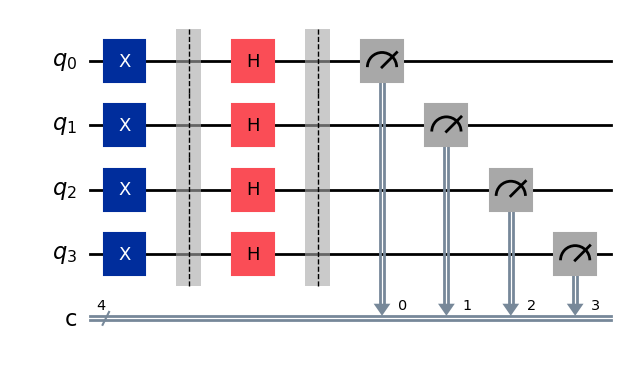

In [ ]:
import random
# from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, execute, Aer #for qiskit version 1.x
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit #for qiskit version 2.x
from qiskit_aer import Aer #for qiskit version 2.x


dj_circuit = QuantumCircuit(4, 4)
dj_circuit.x(0)
dj_circuit.x(1)
dj_circuit.x(2)
dj_circuit.x(3)

dj_circuit.barrier()
dj_circuit.h(0)
dj_circuit.h(1)
dj_circuit.h(2)
dj_circuit.h(3)

dj_circuit.barrier()
dj_circuit.measure(0, 0)
dj_circuit.measure(1, 1)
dj_circuit.measure(2, 2)
dj_circuit.measure(3, 3)

draw = dj_circuit.draw(output='mpl')
display(draw)




In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector

# Create a quantum circuit with 4 qubits
qc = QuantumCircuit(4)

# Initialize the qubits to |1111>
qc.x(0)
qc.x(1)
qc.x(2)
qc.x(3)

# Apply Hadamard gates to all qubits
qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)

# Get the state vector
statevector = Statevector(qc)

# Print the state vector
print(statevector)

Statevector([ 0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j,
              0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j,
              0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,
              0.25+0.j],
            dims=(2, 2, 2, 2))


<h3>Task 2 (Optional)</h3>

Prove the following theorem for registers with arbitrary length.

$$  H^{\otimes n} \ket{x} =  \frac{1}{\sqrt{2^n}} \sum_{z=0}^{2^n-1}(-1)^{x \cdot z}\ket{z}$$


<h3>Task 3 (Discussion)</h3>

- How many times do we need to use the oracle $f$, if we want to solve this problem clasically, in the worst case?

- How many times do you think we will use the oracle $f$ while solving it with a quantum computer?

To check out our solution, run the next cell:

In [ ]:
SolutionToTask3()  # show solution for task 3

<IPython.core.display.Javascript object>

<h3>Task 4</h3>

You are given an oracle function called `oraclej(n)`, which returns a random quantum circuit with `n+1` qubits corresponding to a constant or balanced fuction. `oraclej(n)` represents the $U_f$ in our algorithm.

Let $n=4$. Implement the proposed algorithm to decide whether or not $f$ is constant or even. Note that qubit 4 is the output qubit.

(Note: You should be able the see the circuit structure of $U_f$, if you draw your circuit. Can you check whether your result is correct or not by looking at this circuit?)

Don't forget to run the following cell to load the oracle function.

In [ ]:
quantum_file = path_files+"oracle.py"
%run $quantum_file

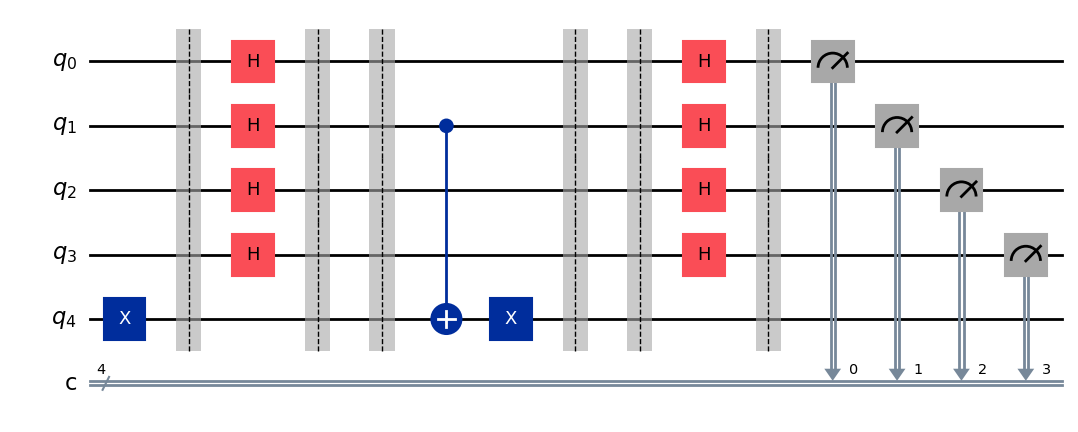

{'0010': 5037, '0000': 4963}


In [ ]:
import random
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import Aer

dj_circuit = QuantumCircuit(5, 4)
dj_circuit.x(4)
dj_circuit.barrier()
dj_circuit.h(0)
dj_circuit.h(1)
dj_circuit.h(2)
dj_circuit.h(3)
dj_circuit.barrier()
dj_circuit.compose(oraclej(4), inplace=True)
dj_circuit.barrier()
dj_circuit.h(0)
dj_circuit.h(1)
dj_circuit.h(2)
dj_circuit.h(3)
dj_circuit.barrier()
dj_circuit.measure(0, 0)
dj_circuit.measure(1, 1)
dj_circuit.measure(2, 2)
dj_circuit.measure(3, 3)
display(dj_circuit.draw(output='mpl'))
simulator = Aer.get_backend('qasm_simulator')
job = simulator.run(dj_circuit,shots=10000)
counts = job.result().get_counts()
print(counts)

To check out our solution, run the next cell:

In [ ]:
SolutionToTask4()  # show solution for task 4

<IPython.core.display.Javascript object>

<h3>Task 5</h3>

Write two functions `balanced(n)` and `constant(n)` to randomly generate quantum circuits with $n+1$ qubits that implement a function $ f : \{0, 1\}^n \rightarrow \{0, 1\} $ such that $f$ is either constant or balanced.

Note that qubit $n$ is the output qubit.

In [ ]:
import random
# from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, execute, Aer #for qiskit version 1.x
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit #for qiskit version 2.x
from qiskit_aer import Aer #for qiskit version 2.x

def balanced(n):
    circuit = QuantumCircuit(n+1)
    circuit.barrier()

    circuit.cx(0, n)

    circuit.barrier()
    return circuit

def constant(n):
    circuit = QuantumCircuit(n+1)
    circuit.barrier()

    circuit.barrier()
    return circuit

    draw = circuit.draw(output='mpl')
    display(draw)

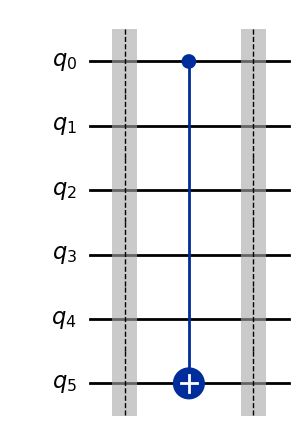

In [ ]:
n = 5
balanced_circuit = balanced(n)
display(balanced_circuit.draw(output='mpl'))

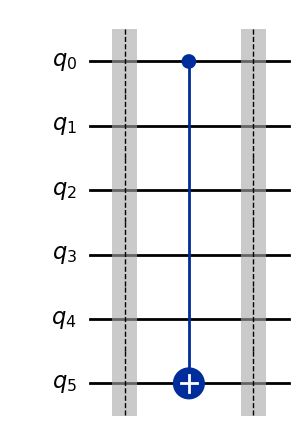

In [ ]:
n=5
balanced(n).draw(output='mpl')
display(balanced_circuit.draw(output='mpl'))

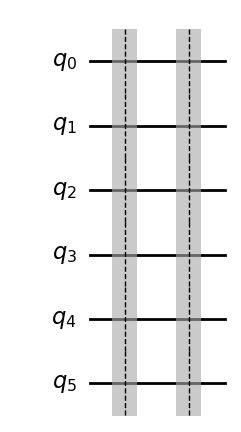

In [ ]:
n=5
constant(n).draw(output='mpl')

To check out our solution, run the next cell:

In [ ]:
SolutionToTask5()  # show solution for task 5

<IPython.core.display.Javascript object>